<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day3_visualization_cafe_data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving dirty_cafe_sales (1).csv to dirty_cafe_sales (1) (1).csv


{'dirty_cafe_sales (1) (1).csv': b'Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date\r\nTXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08\r\nTXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16\r\nTXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19\r\nTXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27\r\nTXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11\r\nTXN_2602893,Smoothie,5,4.0,20.0,Credit Card,,2023-03-31\r\nTXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06\r\nTXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28\r\nTXN_4717867,,5,3.0,15.0,,Takeaway,2023-07-28\r\nTXN_2064365,Sandwich,5,4.0,20.0,,In-store,2023-12-31\r\nTXN_2548360,Salad,5,5.0,25.0,Cash,Takeaway,2023-11-07\r\nTXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,ERROR\r\nTXN_7619095,Sandwich,2,4.0,8.0,Cash,In-store,2023-05-03\r\nTXN_9437049,Cookie,5,1.0,5.0,,Takeaway,2023-06-01\r\nTXN_8915701,ERROR,2,1.5,3.0,,In-store,2023

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/dirty_cafe_sales (1).csv')

#data cleaning
#replace ERROR, UNKNOWN,EMPTY WITH NaN
df.replace(["ERROR","UNKNOWN",""],np.nan, inplace=True)

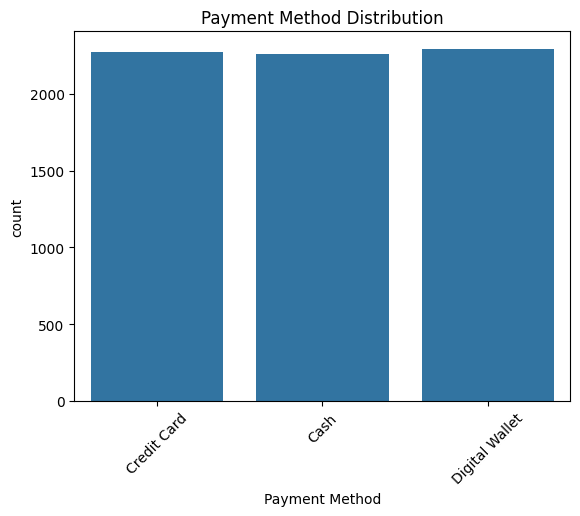

In [ ]:
# Count plot -payment Method Usage
plt.figure()
sns.countplot(data=df, x="Payment Method")
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

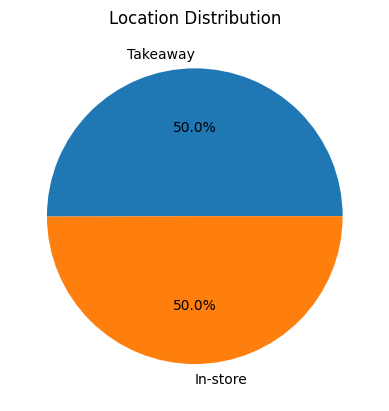

In [ ]:
#Pie Chart - Location Distribution
plt.figure()
location_counts = df["Location"].value_counts()
plt.pie(location_counts, labels=location_counts.index, autopct='%1.1f%%')
plt.title("Location Distribution")
plt.show()

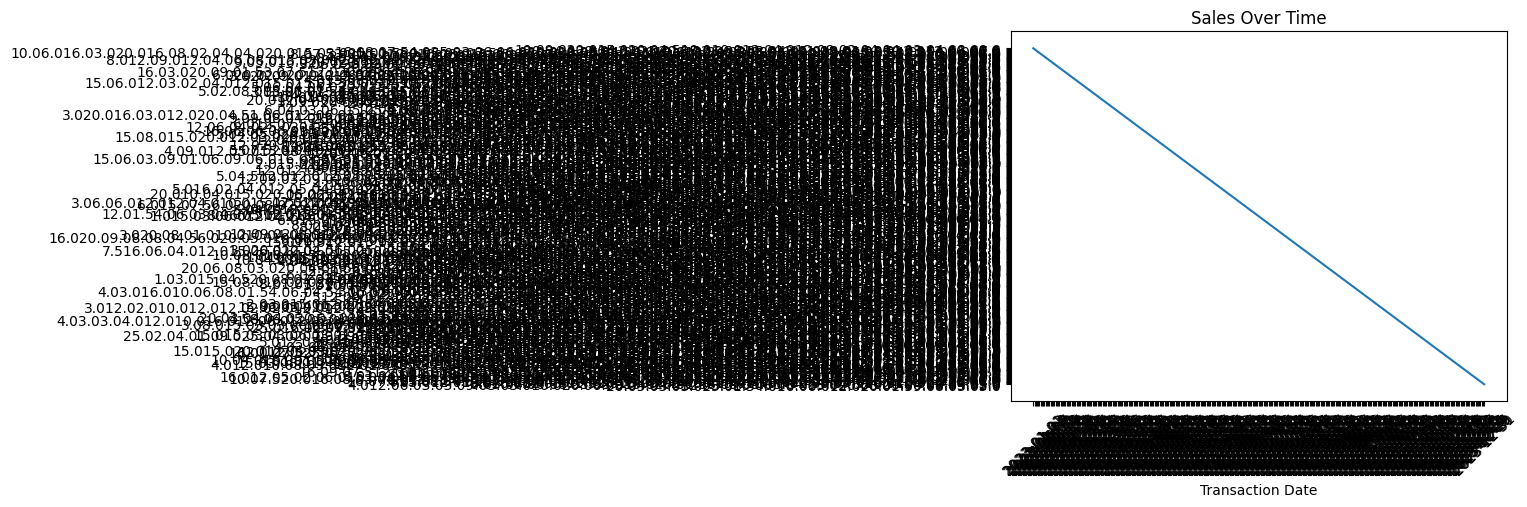

In [ ]:
#Line Plot - Sales Over Time
plt.figure()
daily_sales = df.groupby("Transaction Date")["Total Spent"].sum()
sns.lineplot(x=daily_sales.index, y=daily_sales.values)
plt.title("Sales Over Time")
plt.xticks(rotation=45)
plt.show()


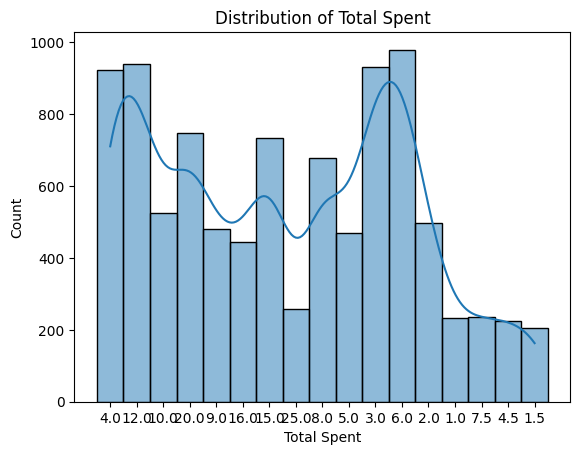

In [ ]:
# Histogram - Distribution of Total Spent
plt.figure()
sns.histplot(df["Total Spent"], bins=5, kde=True)
plt.title("Distribution of Total Spent")
plt.show()


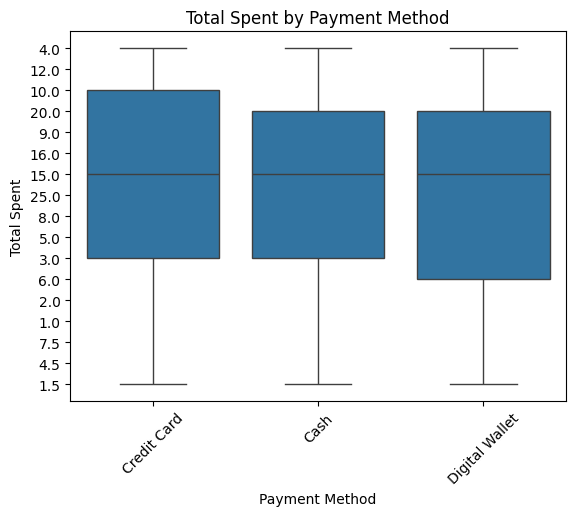

In [ ]:
#Box Plot - Total Spent by Payment Method
plt.figure()
sns.boxplot(data=df, x="Payment Method", y="Total Spent")
plt.title("Total Spent by Payment Method")
plt.xticks(rotation=45)
plt.show()


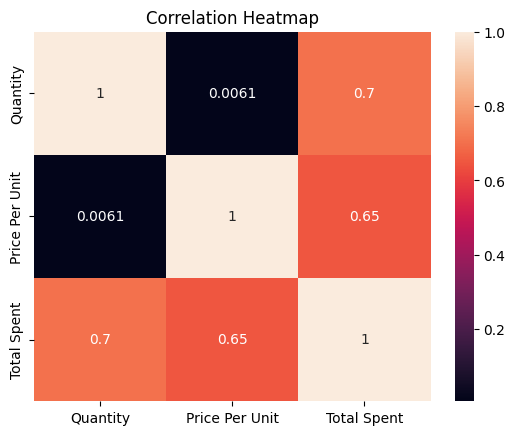

In [ ]:
#Heatmap - Correlation Matrix
plt.figure()
numeric_df = df[["Quantity", "Price Per Unit", "Total Spent"]]
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Make plots look fancy
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
# Convert numeric column properly
df["Quantity"]=pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"]=pd.to_numeric(df["Total Spent"], errors="coerce")

In [ ]:
df["Total Spent"] = df["Total Spent"].fillna(
    df["Quantity"]*df["Price Per Unit"]
)

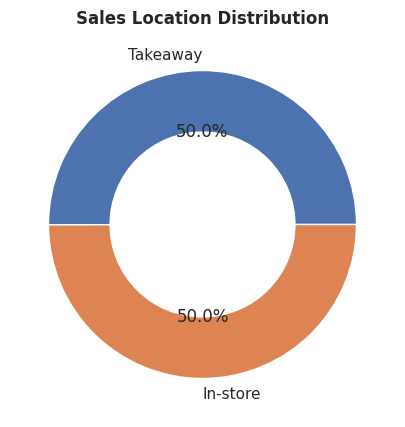

In [ ]:
location_counts = df["Location"].value_counts()

plt.figure()
plt.pie(location_counts,
        labels=location_counts.index,
        autopct='%1.1f%%',
        wedgeprops={"width":0.4})
plt.title("Sales Location Distribution", weight="bold")
plt.show()


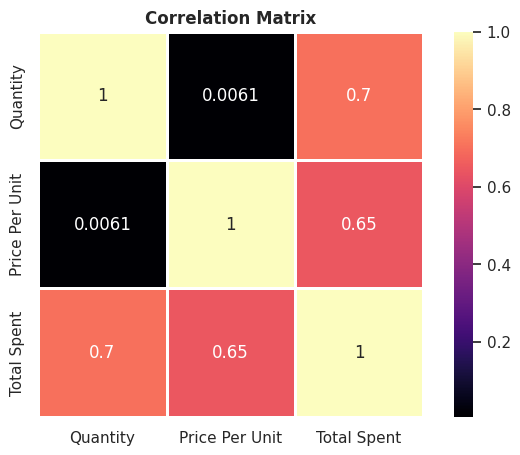

In [ ]:
plt.figure()
corr = df[["Quantity","Price Per Unit","Total Spent"]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="magma",
            linewidths=1,
            linecolor="white",
            square=True
            )
plt.title("Correlation Matrix",weight="bold")
plt.show()




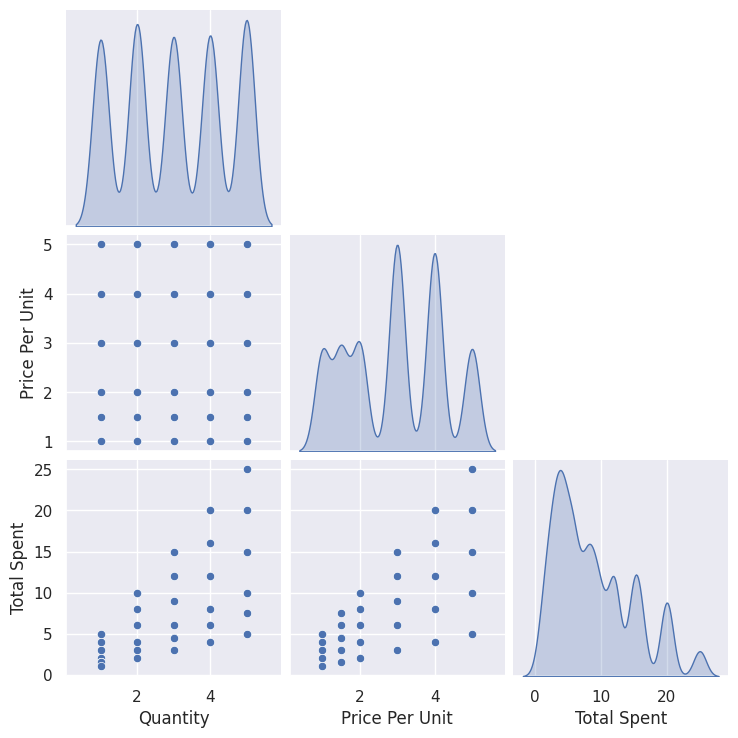

In [ ]:
sns.pairplot(df[["Quantity","Price Per Unit","Total Spent"]],
             diag_kind="kde",
             corner=True)

plt.show()